<font size="4"> 
Far-field heat transfer and persistent heat currents arising in a cylindrical non-reciprocal configuration

</font>


<font size="2">

Guillem Masdemont 
ICFO- L’institut de Ciències 
Thermal photonics research group.
</font>

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.optimize import fsolve
from scipy.optimize import root
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image



plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 25  # General font size
plt.rcParams['axes.titlesize'] = 25  # Title font size

In [18]:
global w0, c

# BOUNDARY CONDITIONS / CONSTANTS:
epsilon_0 = 8.854187817 * 10**(-12)
mu_0 = 1.25663706127 * 10**(-6)
hbar = 1.054571817*10**(-34)
Kb = 1.380649*10**(-23)
c = 299792458
T = 800
sigma = 2*Kb**4*np.pi**5/(15*c**2*(2*np.pi*hbar)**3)  # Planck's law constant
b = 2.897771955*10**(-3)  # Wien's displacement constant.
lambda_peak = b/T
w0 = 2*np.pi*c/lambda_peak

In [3]:
#Blackbody emissivity profile: 

def e(theta, phi):
    return 1
            
def a(theta, phi):
    return e(-theta, phi)

def r(theta, phi):
    return 1 - a(theta, phi)  

In [4]:
#On-Off emissivity profile
def e(theta, phi):
    if phi < 0: 
        phi = phi + 2*np.pi
    if phi > np.pi/2 and phi < 3/2*np.pi: 
        return 0
    else:
        return 1
            
def a(theta, phi):
    return e(-theta, phi)

def r(theta, phi):
    return 1 - a(theta, phi)    

In [5]:
#Weyl semimetal emissivity profile 
def Rp(theta, phi):
    c = 3*10**8
    w = c
    n = 1
    ed = 9 + 0.3j
    exz = 9j
    ev = ed - abs(exz)**2/ed
    e_r = np.array(
        [[ed, 0, exz],
         [0, ed,  0],
         [-exz, 0, ed]], dtype=complex)

    k0 = n*w/c

    kx, ky, kz0 = k0*np.sin(theta)*np.cos(phi), k0 * \
        np.sin(theta)*np.sin(phi), k0*np.cos(theta)
    kz1 = np.sqrt(ev * k0**2 - kx**2)
    r = (kz0 * ev - kz1 + kx*exz/ed)/(kz0 * ev + kz1 - kx*exz/ed)
    return abs(r)**2


def Rs(theta, phi):
    c = 3*10**8
    w = c
    n = 1
    ed = 9 + 0.3j
    exz = 9j
    ev = ed - abs(exz)**2/ed
    e_r = np.array(
        [[ed, 0, exz],
         [0, ed,  0],
         [-exz, 0, ed]], dtype=complex)

    k0 = n*w/c

    kx, ky, kz0 = k0*np.sin(theta)*np.cos(phi), k0 * \
        np.sin(theta)*np.sin(phi), k0*np.cos(theta)
    kz1 = np.sqrt(-kx**2 + k0**2 * ed)
    r = (kz0 - kz1)/(kz0 + kz1)
    return abs(r)**2

def r(theta, phi):
    return 1/2 * (Rp(theta, phi) + Rs(theta, phi))


def a(theta, phi):
    return 1 - r(theta, phi)


def e(theta, phi):
    return a(-theta, phi)

In [ ]:
""" 
Planck's law verification: 
Check: We integrate the mean photon energy over all directions first
"""

# Function to compute the mean photon energy based on Planck's law. 
def Mean_photon_energy(w, T):
    """
    Computes the mean energy of a photon at frequency w and temperature T,
    using Planck's distribution. 
    """
    return (hbar * w) / (np.exp(hbar * w / (Kb * T)) - 1)

# Discrete integration parameters
dpi_w = 1000  # Resolution in frequency domain
dpi_theta = 150  # Resolution in theta (polar angle)
dpi_phi = 150  # Resolution in phi (azimuthal angle)

# Define frequency range for integration (in units of angular frequency w)
w_values = np.linspace(0.0001 * 193710262841590, 30 * 193710262841590, dpi_w) 

# Define angular grids for integration
theta_values = np.linspace(0, np.pi/2, dpi_theta)  # Half-space integration
phi_values = np.linspace(0, 2*np.pi, dpi_phi)  # Full azimuthal range

"""
# Verification Step: Compute emissivity integral over solid angle, we obtain the emissivity integrated over all angles. 
"""

# Theoretical value: \int_0^pi \int_0^2pi sin(theta)cos(theta) dtheta dphi = pi
I = 0
for theta in theta_values:
    for phi in phi_values: 
        I += (1 / np.pi) * np.cos(theta) * np.sin(theta) * (2 * np.pi / dpi_phi) * (np.pi / (2 * dpi_theta)) * e(theta, phi) 

print("Emissivity over all directions: ", float(round(I, 3)))


"""
# Planck's law integration: Compute emissivity integral over solid angle and frequencies, the result should look similar to sigma T**4. 
"""

# Compute Planck's law integration with discrete summation
# Here we don't integrate over all angles, we take the previous value of the last calculation.
I = 0
for w in w_values:
    I += (1/2) * np.pi * (1 / np.pi) * (1 / (2 * np.pi)**2) * (w / c)**2 * Mean_photon_energy(w, T) * (30 * 193710262841590 / dpi_w) * 2  # Factor of 2 for polarization

print('')
print("Planck's law integration result: ", I)
print("Expected value:", sigma * T**4)
print("Relative error: " + str(np.abs(I - sigma * T**4) / (sigma * T**4)))


Emissivity over all directions:  0.589

Planck's law integration result:  23202.70467440022
Expected value: 23225.853663672206
Relative error: 0.00099669056764079


Initial point (alpha0, z0) = (0.0,0).
Direction (phi, theta) = (90.0,30.0).

Next point (alpha1, z1) = (3.141592653589793,1.1547005383792512).
New direction (phi, theta) = (90.0,30.0).

Note: The directions remains unchanged in this coordinate system!


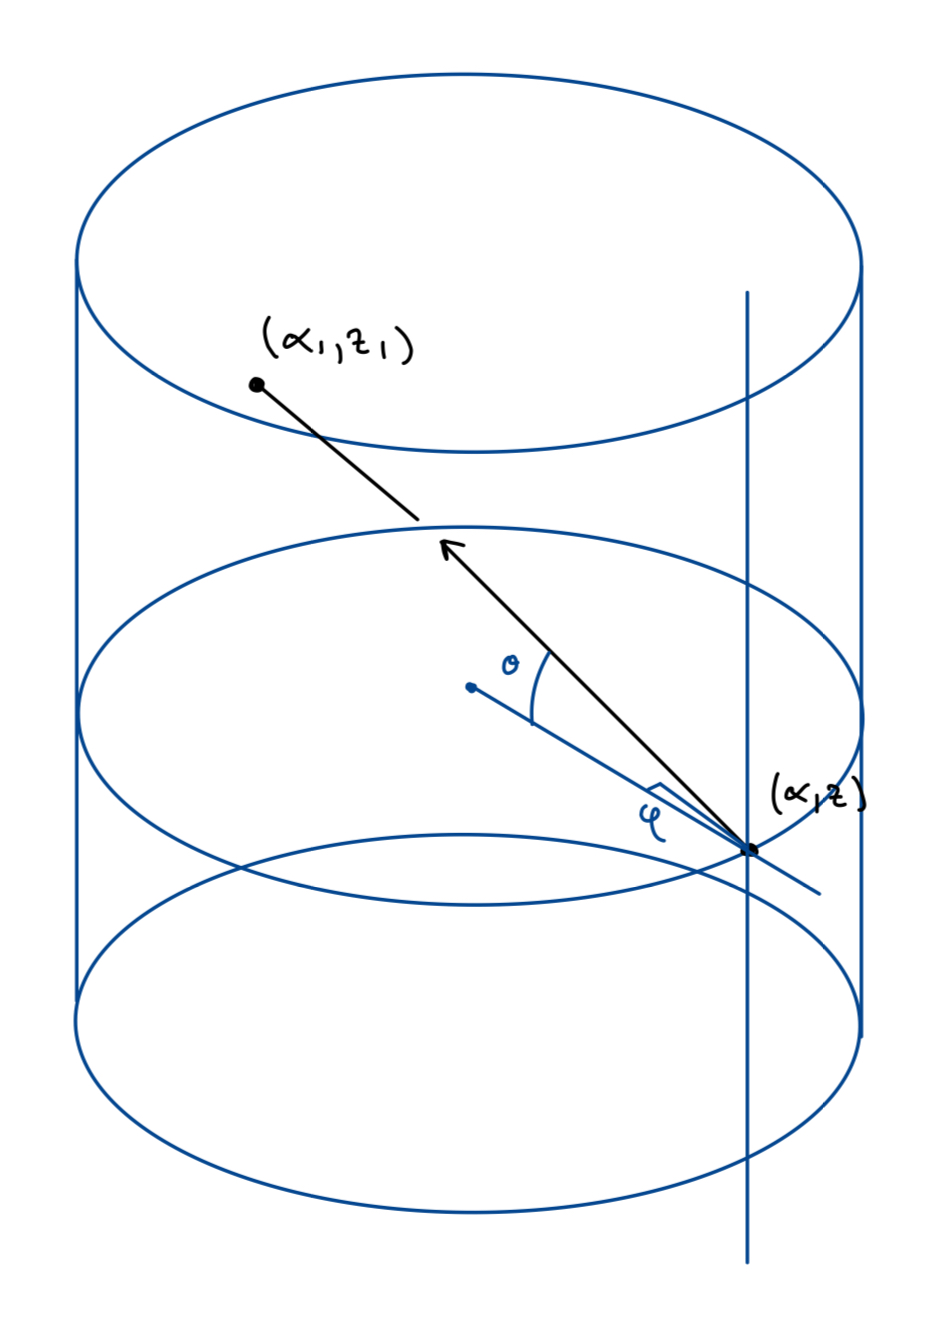

In [52]:
def Next_point(alpha, z, phi, theta):
    """
    Computes the next reflection point within a cylinder for a ray
    starting at position (alpha, z) with direction (phi, theta).
    
    Parameters:
    alpha (float): Initial angular position in cylindrical coordinates.
    z (float): Initial height coordinate.
    phi (float): Azimuthal angle of direction.
    theta (float): Polar angle of direction.

    Returns:
    alpha1 (float): Updated angular position after reflection.
    z1 (float): Updated height coordinate after reflection.
    """

    # Define unit vectors in cylindrical coordinates
    u_alpha = np.array([-np.sin(alpha), np.cos(alpha), 0])  # Tangential direction
    u_z = np.array([0, 0, 1])  # Vertical direction
    u_r = -np.array([np.cos(alpha), np.sin(alpha), 0])  # Radial inward direction

    # Compute velocity vector based on directional angles
    u_v = u_alpha * np.cos(phi) * np.sin(theta) + u_z * np.sin(phi) * np.sin(theta) + u_r * np.cos(theta)

    # Compute initial position in Cartesian coordinates
    P0 = np.array([np.cos(alpha), np.sin(alpha), z])

    # Compute intersection with the cylinder boundary (reflection point)
    t = -2 * (P0[0] * u_v[0] + P0[1] * u_v[1]) / (u_v[0]**2 + u_v[1]**2)

    # Compute new position after reflection
    P1 = P0 + t * u_v

    # Convert back to cylindrical coordinates
    z1 = P1[2]  # New height
    alpha1 = np.arccos(P1[0])  # Compute angular coordinate

    # Ensure correct quadrant for alpha1 using arcsin check
    if np.arcsin(P1[1]) < 0:
        alpha1 = -alpha1

    return alpha1, z1

#Check up example: 

# Initial conditions
alpha0 = np.pi / 180 * 0  # Initial angle in radians
z0 = 0  # Initial height

# Direction angles (in local coordinate system)
phi0 = np.pi / 180 * 90  # Azimuthal angle
theta0 = np.pi / 180 * 30  # Polar angle (parallel to the surface)

# Compute the next reflection point
print("Initial point (alpha0, z0) = (" + str(alpha0) + "," + str(z0) + ").")
print("Direction (phi, theta) = (" + str(float(round(phi0 * 180 / np.pi, 2))) + "," + str(float(round(theta0 * 180 / np.pi, 2))) + ").")
print("")
alpha1 =Next_point(alpha0, z0, phi0, theta0)[0]
z1 = Next_point(alpha0, z0, phi0, theta0)[1] 
print("Next point (alpha1, z1) = (" + str(alpha1) + "," + str(z1) + ").")
print("New direction (phi, theta) = (" + str(float(round(phi0 * 180 / np.pi, 2))) + "," + str(float(round(theta0 * 180 / np.pi, 2))) + ").")

print('')
print("Note: The directions remains unchanged in this coordinate system!")
#Display a representation: 
Image(filename="Cylinder.jpg", width=400, height=300)

In [ ]:
# Number of elements for transmission coefficient computation
n_elem = 10


def S_p_k(alpha, z, kx, ky):
    """
    Computes the heat transmission coefficient to each element for a given point (alpha, z) and direction (kx, ky). 
    
    Input: Enter the position of a point and direction given in wave vector notation.
    Output: Returns the transmission coefficient for each element in an ordered vector list. 

    Notation: See report for (alpha, z) coordinates. 
    """
    # Define the element angle boundaries of the cylinder by specifying the angles. 
    elem_values = [(2 * np.pi) / n_elem * i for i in range(n_elem + 1)]
    
    # Initialize array for storing transmission coefficients
    S_p_k_values = np.zeros(n_elem)
    
    # Transformation from (kx, ky) to (theta, phi)
    kparal = np.sqrt(kx**2 + ky**2)  # Parallel wave vector component
    k = w0 / c  # Wave number
    theta = np.arcsin(min(1, kparal / k))  # Incident angle, ensuring valid input range
    phi = np.arctan2(ky, kx)  # Azimuthal angle
    
    # Initial value given by emissivity
    s = e(theta, phi)  
    
    # Iterate through multiple reflection steps (fixed at 25 iterations, can be adaptive)
    while s > 10**(-5):
        alpha, z = Next_point(alpha, z, phi, theta)  # Compute next position of the reflected ray
        
        # Determine which element receives the transmission
        for j in range(n_elem):
            if elem_values[j] <= alpha % (2 * np.pi) < elem_values[j + 1]:
                S_p_k_values[j] += s * a(-theta, phi)  # The elements absorbes according to the absorptivity profile. 
                s *= r(-theta, phi)  # The rest is reflected
           
    return S_p_k_values

#Check up:

# Initial Conditions:
alpha = np.pi / 180 * 0  # Initial angle (0 degrees)
z = 0  # Initial z-position

# Direction:
phi0 = np.pi / 180 * 10  # Azimuthal angle (10 degrees)
theta0 = np.pi / 180 * 45  # Incident angle (45 degrees)

# Compute wave vector components
kx = w0 / c * np.sin(theta0) * np.cos(phi0)
ky = w0 / c * np.sin(theta0) * np.sin(phi0)

# Compute and display the transmission coefficients
transmission_values = S_p_k(alpha, z, kx, ky)

print("The transmission value for each element of the cylinder:")
print([float(round(x, 2)) for x in transmission_values])

# Ensure the sum of transmission coefficients matches 
print('')
print("Check up: The emissivity of the point corresponds to the sum of absorptivities")
print("Emission value: " + str(e(theta0, phi0)))
print("Sum of absorptions:" + str(sum(transmission_values)))

The transmission value for each element of the cylinder:
[0.02, 0.0, 0.42, 0.0, 0.0, 0.15, 0.0, 0.05, 0.0, 0.0]

Check up: The emissivity of the point corresponds to the sum of absorptivities
Emission value: 0.6458960664645783
Sum of absorptions:0.6458889772046205


In [56]:
# Computes the heat transmission coefficient for a point p, integrating over all directions k.
# This is done by using as integrand the previous functions S_p_k

def S_p(alpha, z):
    """
    Computes the integral of the transmission coefficient over all possible directions of wavevector k||.
    The value of the integral may exceed 1, as it is essentially summing over all possible wavevectors 
    that contribute to the emission/absorption at a point.
    
    Parameters:
    alpha (float): The angular position of the point in cylindrical coordinates.
    z (float): The height coordinate of the point.
    
    Returns:
    np.array: Transmission coefficients for each element.
    """
    # Define the angular positions in the range 0 to 2*pi for the number of elements in the cylinder
    elem_values = [(2*np.pi)/n_elem * i for i in range(0, n_elem+1)]
    S_p_values = np.zeros(n_elem)  # Array to store the computed transmission coefficients
    
    # Discretize the k-space (wavevector components kx, ky)
    dpi_kx = 150  # Resolution for the kx values
    kx_values = np.linspace(-w0/c, w0/c, dpi_kx)  # Range of kx values from -w0/c to w0/c
    ky_values = kx_values  # Same for ky since it's a circular symmetry
    
    # Loop over all kx, ky values to compute the transmission coefficient
    for kx in kx_values:
        for ky in ky_values:
            if kx**2 + ky**2 < (w0/c)**2:  # Check if (kx, ky) is inside the allowed circular region
                # Accumulate the transmission coefficient for each (kx, ky) direction
                S_p_values += S_p_k(alpha, z, kx, ky) * 2*w0/(c*dpi_kx) * 2*w0/(c * dpi_kx)
    
    # Normalize by the area of the allowed k-space (ensures the correct scaling)
    return S_p_values / (np.pi * (w0/c)**2)

#Check up: 

print("The transmission value for each element of the cylinder emitted by a point in all directions:")
print([float(round(x, 2)) for x in S_p(alpha, z)])

print('')
print("The total emissivity of the point (computed previously)")
print("equal to the sum of the contributions from all elements: " + str(sum(S_p(alpha, z))))
print("")

The transmission value for each element of the cylinder emitted by a point in all directions:
[0.02, 0.03, 0.06, 0.09, 0.11, 0.1, 0.08, 0.05, 0.03, 0.02]

The total emissivity of the point (computed previously)
equal to the sum of the contributions from all elements: 0.5848253863554768



In [ ]:
# Computes the average emission coefficient using two different integration methods: one with wavevector components and one with angular coordinates
def e_p():
    """
    Computes the average emission coefficient in two ways:
    1. Integration over wavevector components (kx, ky)
    2. Integration over angular coordinates (theta, phi)
    
    Parameters:
    alpha (float): The angular position of the point in cylindrical coordinates.
    z (float): The height coordinate of the point.
    
    Returns:
    tuple: The two computed values of the emission coefficient.
    """
    # First integration method: over wavevector components (kx, ky)
    e_k = 0
    dpi_kx = 500  # Resolution for the kx values
    kx_values = np.linspace(-w0/c, w0/c, dpi_kx)  # Range of kx values
    ky_values = kx_values  # Same for ky
    
    # Loop over all (kx, ky) values and compute the emission coefficient
    for kx in kx_values:
        for ky in ky_values:
            if kx**2 + ky**2 < (w0/c)**2:  # Ensure we're inside the allowed k-space region
                kparal = np.sqrt(kx**2 + ky**2)  # Parallel wavevector magnitude
                k = w0/c  # Wavevector magnitude
                theta = np.arcsin(kparal / k)  # Polar angle from k-parallel
                phi = np.arctan2(ky, kx)  # Azimuthal angle from kx, ky
                # Accumulate the emission coefficient for this (kx, ky) direction
                e_k += e(theta, phi) * (2 * w0 / (c * dpi_kx))**2
    
    # Second integration method: over angular coordinates (theta, phi)
    dpi_angles = 100  # Resolution for angular coordinates (theta, phi)
    theta_values = np.linspace(0, np.pi/2, dpi_angles)  # Polar angle values
    phi_values = np.linspace(0, 2*np.pi, dpi_angles)  # Azimuthal angle values
    
    e_theta = 0
    for theta in theta_values:
        for phi in phi_values: 
            # Accumulate the emission coefficient for each (theta, phi) direction
            e_theta += e(theta, phi) * np.cos(theta) * np.sin(theta) * (2*np.pi / dpi_angles) * (np.pi / (2 * dpi_angles))
    
    # Return the two methods of computing the emission coefficient
    return e_k / (np.pi * (w0/c)**2), e_theta / np.pi


#Check up: 

e_k, e_theta = e_p()

print("Overall emissivity integrated with k: " + str(e_k))
print("Overall emissivity integrated with theta: " + str(e_theta))

Overall emissivity integrated with k: 0.5904166245988118
Overall emissivity integrated with theta: 0.5306057208041589


In [63]:
# Computes the transmission coefficient of a slice to the other slices in the system
def S_z():
    """
    Computes the transmission coefficient of a slice to the other slices by integrating the transmission
    coefficient S_p(alpha, z) over different angular positions alpha.
    
    Returns:
    np.array: Transmission coefficient for each element.
    """
    # Discretize alpha values, which represent the angular positions in cylindrical coordinates
    dpi_alpha = 10
    alpha_values = np.linspace(0, 2*np.pi/n_elem, dpi_alpha)  # Range of alpha values, discretized
    S_z_values = np.zeros(n_elem)  # Array to store the computed transmission coefficients
    
    # Loop over teh points in the cylinder and accumulate the corresponding transmission coefficients
    for alpha in alpha_values: 
        # Accumulate S_p(alpha, z) weighted by the angular spacing
        S_z_values += S_p(alpha, z) * 2 * np.pi / (n_elem * dpi_alpha)
    
    # Normalize by the total angular range (to compute the average)
    return S_z_values / (2 * np.pi / n_elem)


print("Transmission coefficient from one slice to the others:")
print(S_z())

Transmission coefficient from one slice to the others:
[0.01967306 0.02541105 0.0457254  0.07587942 0.10024252 0.10449394
 0.08787648 0.06200176 0.03914796 0.02437379]


<font size="5">
Plotting 
</font>

<font size="2">
We store the values we obtain from the function S_z() function by different materials and symetries:
</font>

In [ ]:
#On_off_material

# N = 10 elements
"""
M_info = [0.00738479, 0.04677882, 0.0895342,  0.12324959, 0.14499652, 0.07621612,
 0. ,        0.    ,     0.    ,     0.        ]
"""

#N = 15 elements
"""
M_info =  [0.00272473, 0.02085566 ,0.04155854, 0.06007144, 0.07573229, 0.08856654,
 0.09714818 ,0.08698773 ,0.01451493, 0. ,       0.  ,       0.,
 0.   ,      0.  ,       0.        ]
"""

#N = 20 elements
"""
M_info =  [0.0013751 , 0.01120451, 0.02386051, 0.03491223, 0.04504722, 0.05429093,
 0.06208316, 0.06816925 ,0.07308395 ,0.07563043, 0.03850276, 0.,
 0.      ,   0.    ,     0.    ,     0.  ,       0. ,        0.,
 0.      ,   0. ,       ]
"""

#N = 30 elements
"""
M_info = [0.00053476, 0.0041253 , 0.01089893 ,0.01586456, 0.02067741, 0.0258213,
 0.03002299 ,0.03422468, 0.03806986 ,0.04130389, 0.04443606, 0.04688068,
 0.04856136, 0.0502675,  0.05077679, 0.02569397, 0.     ,    0.,
 0.    ,     0.    ,     0.    ,     0.       ,  0.    ,     0.,
 0.    ,     0.    ,     0.      ,   0.  ,       0.  ,       0.        ]
"""

#N = 50 elements
"""
M_info = [0.00010186, 0.0012987 , 0.00305577 ,0.00590783, 0.00791955, 0.00960023,
 0.01079707, 0.01349634, 0.01471865, 0.01662851, 0.01782535, 0.01963335,
 0.02100845, 0.02268913, 0.02360586 ,0.02480271 ,0.02597409, 0.02696721,
 0.02783302 ,0.02841871 ,0.02920812, 0.0298702,  0.03017578 ,0.0308124,
 0.03060868, 0.01520248, 0.       ,  0. ,        0.      ,   0.,
 0.    ,     0.     ,    0.    ,     0.   ,      0.    ,     0.,
 0.     ,    0.   ,      0.     ,    0.   ,      0.    ,     0.,
 0.     ,    0.  ,       0.      ,   0.   ,      0.     ,    0.,
 0.      ,   0.        ]
"""

#N = 100 elements
"""
M_info = [5.65884242e-05, 5.65884242e-04, 9.05414787e-04, 1.35812218e-03,
 1.89005337e-03, 2.47857298e-03, 2.45593761e-03, 3.90460127e-03,
 3.66692989e-03, 4.45916783e-03, 4.53839162e-03, 5.48907715e-03,
 5.54566557e-03, 6.16813824e-03, 6.70006943e-03, 6.86983470e-03,
 7.59416653e-03, 7.80920254e-03, 8.40903984e-03, 8.60144048e-03,
 9.08810093e-03, 9.54080832e-03, 9.94824498e-03, 1.00727395e-02,
 1.06838945e-02, 1.09328836e-02, 1.13629556e-02, 1.15893093e-02,
 1.18948868e-02, 1.22683704e-02, 1.24834064e-02, 1.27663485e-02,
 1.32190559e-02, 1.32530090e-02, 1.35585864e-02, 1.38075755e-02,
 1.41131530e-02, 1.41471061e-02, 1.45771781e-02, 1.43621421e-02,
 1.47469433e-02, 1.49732970e-02, 1.50072501e-02, 1.51091093e-02,
 1.51204269e-02, 1.52901922e-02, 1.54146868e-02, 1.53807337e-02,
 1.55052282e-02, 1.56070874e-02, 7.59416653e-03, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]
"""


In [ ]:
#Weyl semimetal: 
"""    
M_info = [0.01849329 ,0.02446264, 0.04656642, 0.08228885 ,0.1119545 , 0.11308315,
 0.08676216 ,0.05509803 ,0.03383376 ,0.02220954]
"""

"""
M_info = [0.01201793, 0.01352725, 0.01925509, 0.03043824, 0.04636216, 0.06350096,
 0.07568375, 0.07873264, 0.07172166, 0.05795614, 0.04301041, 0.03065138,
 0.02220085, 0.01663392, 0.01305995]
"""

In [ ]:
#Blackbody: 
"""
M_info = [0.01476958, 0.04677882, 0.0895342 , 0.12324959 ,0.14499652, 0.15243224,
     0.14499652, 0.12324959, 0.0895342,  0.04677882]
"""

Non-reciprocity factor value: 0.13473784


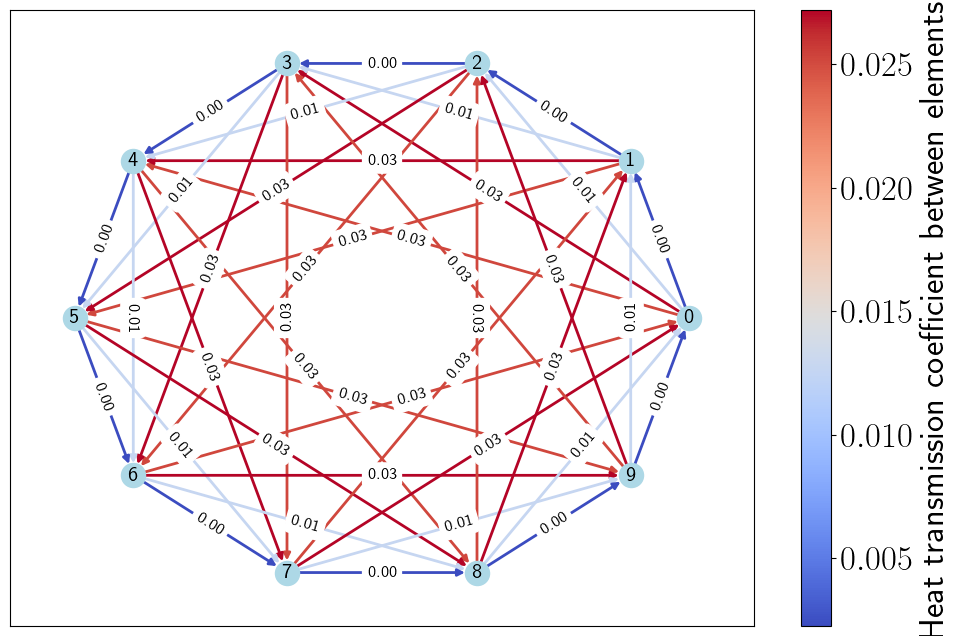

In [71]:
M_info = [0.01849329 ,0.02446264, 0.04656642, 0.08228885 ,0.1119545 , 0.11308315,
 0.08676216 ,0.05509803 ,0.03383376 ,0.02220954]

# Set the number of elements in M_info and initialize the adjacency matrix 'G'
n_elem = len(M_info)
G = np.zeros((n_elem, n_elem))

# Loop through each pair of elements (i, j) to populate the matrix G
# M_info[j-i] is used to define the value for each (i, j) pair in the matrix (we use the symmetry of the cylinder!)
for i in range(n_elem):
    for j in range(n_elem):
        G[i][j] = M_info[j-i]  

# Create the matrix 'T', which is the difference between G and its transpose (G - G.T)
T = G - G.T

# Initialize the reciprocity coefficient 'mu' which will store the average of the absolute values of the off-diagonal elements of T
mu = 0

# Loop through the elements of T to calculate 'mu' and adjust any non-positive entries in T
for i in range(len(T)):
    for j in range(len(T)):
        mu += abs(T[i][j])/len(T)  # Calculate average of absolute values
        if T[i][j] <= 0:
            T[i][j] = 0  # Set any non-positive values in T to zero



# Print the computed average mu value
print('Non-reciprocity factor value: ' + str(mu))





# Create a directed graph (DiGraph) from the numpy array 'T' using NetworkX
G = nx.from_numpy_array(T, create_using=nx.DiGraph)

# Normalize edge weights to the range [0, 1] using the minimum and maximum values of the edge weights
edge_weights = np.array([d['weight'] for u, v, d in G.edges(data=True)])  # Extract edge weights
norm = mcolors.Normalize(vmin=edge_weights.min(), vmax=edge_weights.max())  # Normalize the weights
cmap = plt.cm.coolwarm  # Use pyplot to access the colormap

# Map edge weights to colors using the colormap
edge_colors = [cmap(norm(d['weight'])) for u, v, d in G.edges(data=True)]  # Color edges based on their weights
pos = nx.circular_layout(G)

fig, ax = plt.subplots(figsize=(12, 8), dpi=100)  # Set the figure size and resolution

# Draw the nodes with light blue color, size 300, and add them to the plot
# Draw the edges with arrows and color them according to edge weights
# Draw the node labels (optional, based on your needs)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=300, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color=edge_colors, width=2, edge_cmap=cmap, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif')

edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=12)

# Add a colorbar to show the scale of edge weights
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Set an empty array for the colorbar to work properly
# Colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Heat transmission coefficient between elements')

# Set a title for the plot (optional)
plt.title("")  # You can add a title if needed

# Display the plot
plt.show()
